<a href="https://colab.research.google.com/github/DavidPardo3718/NutriGymDP/blob/main/suplementos_kmeans_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
# Dataset ficticio de suplementos alimenticios
data = {
    "Proteina": [25, 30, 20, 15, 28, 35, 5, 10, 8, 12],
    "Carbohidratos": [5, 2, 10, 20, 3, 1, 25, 22, 30, 18],
    "Grasas": [2, 1, 5, 8, 3, 2, 7, 6, 9, 8],
    "Precio": [25, 30, 20, 15, 28, 35, 10, 12, 8, 14],
    "Popularidad": [500, 600, 450, 400, 550, 620, 300, 320, 280, 310]
}
df = pd.DataFrame(data)
print(df)

   Proteina  Carbohidratos  Grasas  Precio  Popularidad
0        25              5       2      25          500
1        30              2       1      30          600
2        20             10       5      20          450
3        15             20       8      15          400
4        28              3       3      28          550
5        35              1       2      35          620
6         5             25       7      10          300
7        10             22       6      12          320
8         8             30       9       8          280
9        12             18       8      14          310


In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [6]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [7]:
# Definir número de clusters (3 como ejemplo)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_data)

# Agregar al DataFrame
df['Cluster'] = clusters
print(df)

   Proteina  Carbohidratos  Grasas  Precio  Popularidad  Cluster
0        25              5       2      25          500        1
1        30              2       1      30          600        1
2        20             10       5      20          450        2
3        15             20       8      15          400        0
4        28              3       3      28          550        1
5        35              1       2      35          620        1
6         5             25       7      10          300        0
7        10             22       6      12          320        0
8         8             30       9       8          280        0
9        12             18       8      14          310        0


In [8]:
sil_score = silhouette_score(pca_data, clusters)
print(f"Puntaje de Silhouette: {sil_score:.2f}")

Puntaje de Silhouette: 0.44


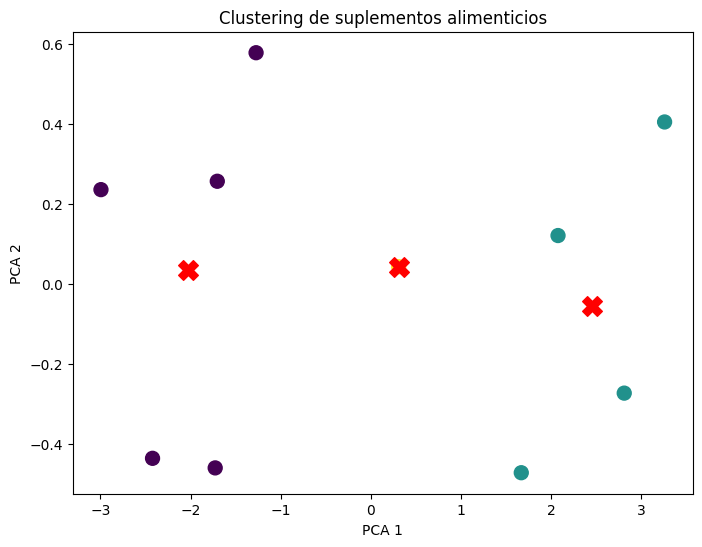

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', marker='X', s=200)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clustering de suplementos alimenticios")
plt.show()

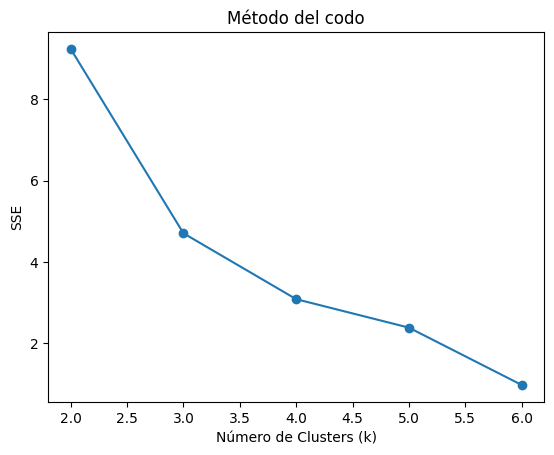

In [10]:
sse = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(pca_data)
    sse.append(km.inertia_)

plt.plot(range(2, 7), sse, marker='o')
plt.xlabel("Número de Clusters (k)")
plt.ylabel("SSE")
plt.title("Método del codo")
plt.show()

In [12]:
# Proyecto: K-Means + PCA con Dataset Iris
# Autor: [Equipo 5]
# Fecha: [08/08/2025]
# Descripción: Implementación de algoritmos de agrupación y reducción de dimensionalidad
